In [109]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm

%matplotlib inline

## 📚 Импорт библиотек

Загружаем необходимые инструменты:
- `pandas`, `numpy` - работа с данными и числовыми операциями
- `matplotlib` - визуализация
- `tqdm` - прогресс-бары для итераций

## Считаем данные соревнования от MTS по RecSys

Датасет можно скачать отсюда: [ссылка](https://github.com/MobileTeleSystems/RecTools/tree/main/datasets/KION)

In [110]:
df = pd.read_csv('../../interactions.csv')
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


### 🔍 Анализ данных

Смотрим на размерность датасета:
- **962,179 уникальных пользователей**
- **15,706 уникальных фильмов/сериалов**
- Период данных: март - август 2021

In [111]:
df.user_id.nunique(), df.item_id.nunique()

(962179, 15706)

In [112]:
df.last_watch_dt.min(), df.last_watch_dt.max()

('2021-03-13', '2021-08-22')

### 📅 Преобразование дат

Конвертируем даты в числовой формат (дни с начала периода):
- Упрощает работу с временными рядами
- Позволяет использовать время как признак в моделях
- День 0 = 13 марта 2021

In [113]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
1445261,291323,14733,87,810,13.0
4716182,523208,13937,56,5362,100.0
1113067,1000047,4238,46,4815,93.0
1271024,577358,5535,46,3653,1.0
2166252,186560,1785,162,76405,100.0


## Popular bias

<Axes: xlabel='index'>

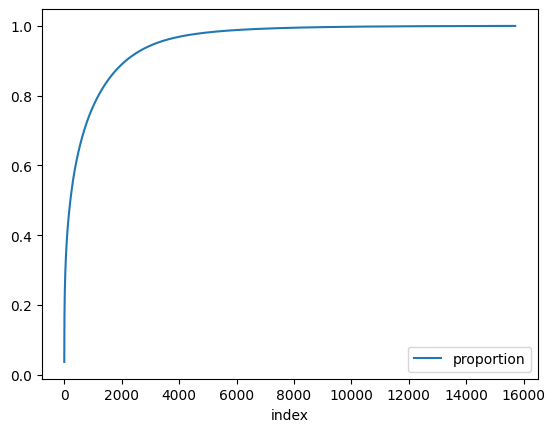

In [114]:
g = df.item_id.value_counts(True).cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

<Axes: xlabel='index'>

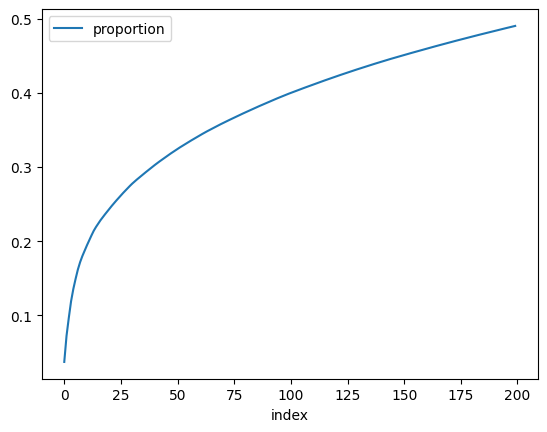

In [115]:
g = df.item_id.value_counts(True)[:200].cumsum().reset_index().reset_index()
g.plot(x='index', y='proportion')

### ⚠️ Важное наблюдение о Popular Bias

**Вывод:** Топ-200 фильмов покрывают значительную долю всех просмотров!

Это типичный эффект "длинного хвоста" в рекомендательных системах:
- Небольшая часть айтемов получает большинство взаимодействий
- Важно учитывать популярность при построении рекомендаций

## Популярность айтема по времени

<Axes: >

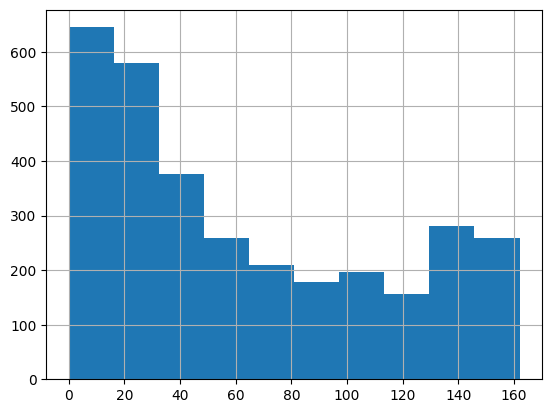

In [116]:
popular_items = df.item_id.value_counts()[:300].index.tolist()

sampled_id = np.random.choice(popular_items)

interactions = df.loc[df.item_id==sampled_id].copy()
interactions.last_watch_dt.hist()

In [117]:
temp = df.groupby('item_id').agg({'last_watch_dt':'max'}).reset_index()
temp = temp.loc[temp.item_id.isin(popular_items)].copy()
temp = temp.sort_values(by='last_watch_dt')
temp.head()

,item_id,last_watch_dt
6751,7107,87
8359,8801,140
11826,12463,141
4486,4716,141
14,14,162


<Axes: >

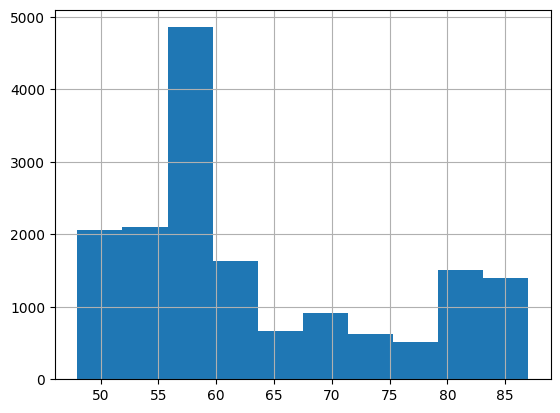

In [118]:
interactions = df.loc[df.item_id==7107].copy()
interactions.last_watch_dt.hist()

### 📉 Временная релевантность контента

**Проблема:** Некоторые популярные фильмы редко встречаются в конце периода (последняя дата просмотра далеко от теста).

**Почему это важно:**
- Такие айтемы вряд ли будут релевантны для тестового периода
- Нужно учитывать "свежесть" контента при формировании рекомендаций

этот айтем не встретится в тесте скорее всего, хоть он и популярный

## Сделаем протокол тестирования

<Axes: >

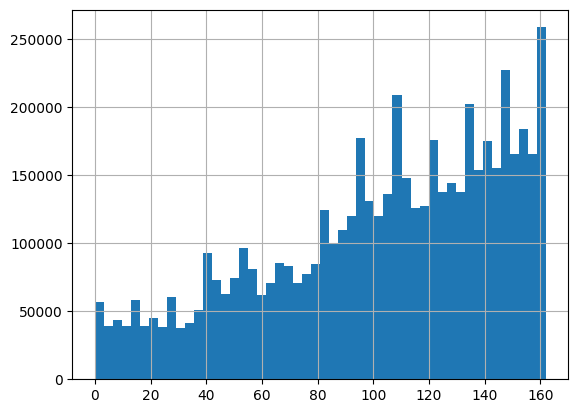

In [119]:
df.last_watch_dt.hist(bins=50)

In [120]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


### ✂️ Создание протокола тестирования

**Стратегия split:**
- Train: все взаимодействия до дня 153 (160-7)
- Test: взаимодействия с дня 153 и позже

**Почему временной split:**
- Симулирует реальный продакшн: модель обучена на прошлом, предсказывает будущее
- Избегаем data leakage - модель не видит будущих данных

In [121]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

### 👥 Анализ пользователей

**Результаты:**
- 134,670 пользователей есть и в train, и в test
- 37.8% пользователей в test'е - "холодные" (не были в train)

**Решение:** Работаем только с пользователями, которые есть в обоих множествах (это задача предсказания для "теплых" пользователей)

## Теперь переведем к соединенному датасету все

In [122]:
n_users = 5000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users


### 🎲 Сэмплирование для ускорения экспериментов

Берем случайные 5000 пользователей для быстрого прототипирования:
- Ускоряет обучение и оценку моделей
- Сохраняет репрезентативность данных
- В продакшене используется вся выборка

In [123]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
109,614119,14362,92,5074,94.0
191,729106,14961,152,3625,57.0
219,217512,10942,145,3984,48.0
329,1045343,13218,78,331,7.0
413,109406,9937,143,7401,96.0


In [124]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id, 
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_20487/1639636907.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('user_id').apply(
/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_20487/1639636907.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('user_id').apply(


,user_id,train_interactions
0,590,"[(4030, 30), (4359, 33), (16346, 56), (14461, ..."
1,654,"[(11237, 3), (6273, 4), (11936, 4), (14646, 4)..."
2,684,"[(11237, 36), (3309, 42), (7417, 42), (5658, 4..."
3,866,"[(4582, 35), (6948, 35), (15212, 50), (6645, 6..."
4,1813,"[(4997, 0), (12146, 9)]"


### 🗂️ Подготовка данных для рекомендаций

Группируем взаимодействия по пользователям и сортируем по времени:
- Для каждого пользователя создаем список (item_id, timestamp)
- Порядок важен: показывает историю просмотров пользователя
- Формат удобен для генерации и оценки рекомендаций

In [125]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,590,"[(4030, 30), (4359, 33), (16346, 56), (14461, ...","[(10440, 160)]"
1,654,"[(11237, 3), (6273, 4), (11936, 4), (14646, 4)...","[(1337, 153), (12192, 153), (984, 153), (341, ..."
2,684,"[(11237, 36), (3309, 42), (7417, 42), (5658, 4...","[(341, 162)]"
3,866,"[(4582, 35), (6948, 35), (15212, 50), (6645, 6...","[(512, 153)]"
4,1813,"[(4997, 0), (12146, 9)]","[(6764, 157)]"


In [126]:
def ndcg_metric(gt_items, predicted):
    
    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)),
                  dtype=np.float64)


def recall_metric(gt_items, predicted):
    
    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / min(n_gt, len(gt_items))



def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return {'ndcg':np.mean([x[0] for x in metric_values]),
            'recall':np.mean([x[1] for x in metric_values])}
            


In [127]:
gt = [1, 42, 3461, 572, 234]
preds = [1]

recall_metric(gt, preds), ndcg_metric(gt, preds)

(0.2, np.float64(1.0))

In [128]:
def get_metrics(df, model_preds, gt_col='test_interactions', topn=10):
    
    metric_values = []
    
    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        metric_values.append((ndcg_metric(gt_items, row[model_preds]),
                              recall_metric(gt_items, row[model_preds])))
        
    return metric_values
        

### 📊 Метрики качества рекомендаций

**NDCG (Normalized Discounted Cumulative Gain):**
- Учитывает порядок рекомендаций (первые позиции важнее)
- Диапазон [0, 1], где 1 - идеальное качество
- Штрафует за неправильный порядок релевантных айтемов

**Recall@K:**
- Доля релевантных айтемов, которые попали в топ-K рекомендаций
- Простая, интерпретируемая метрика
- Не учитывает порядок (в отличие от NDCG)

## Построим EASE

In [129]:
item2id = {k: v for v, k in enumerate(train_df.item_id.unique())}
user2id = {k:v for v, k in enumerate(train_df.user_id.unique())}

id2item = {k:v for v, k in item2id.items()}
id2user = {k:v for v, k in user2id.items()}

train_df['user_id'] = train_df.user_id.apply(lambda x: user2id[x])
train_df['item_id'] = train_df.item_id.apply(lambda x: item2id[x])

train_df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
5324265,1289,260,107,133,2.0
4373310,281,3774,84,5430,97.0
2680535,1340,1214,13,360,6.0
1964100,1013,101,14,1910,43.0
4945314,1911,23,145,57646,88.0


In [130]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(train_df.shape[0]), (train_df['user_id'], train_df['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 61074 stored elements and shape (5000, 5491)>

### 🎯 Модель EASE (Embarrassingly Shallow Autoencoders)

**Что это:**
- Линейная модель коллаборативной фильтрации
- Решает задачу автокодировщика с закрытой формулой (closed-form solution)
- Очень проста, но удивительно эффективна!

**Как работает:**
1. Строим матрицу взаимодействий X (users × items)
2. Вычисляем G = X^T @ X (граммова матрица, item-item similarity)
3. Добавляем регуляризацию: G += λI
4. Инвертируем: P = G^(-1)
5. Получаем веса: B = P / (-diag(P)), где diag(B) = 0

**Параметр reg_weight (λ):**
- Контролирует регуляризацию (сложность модели)
- Большие значения = более простая модель, меньше переобучение
- λ=2000 - типичное значение для этого датасета

In [131]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole

def fit_ease(X, reg_weight=2000):
    
    # gram matrix
    G = X.T @ X

    # add reg to diagonal
    G += reg_weight * sps.identity(G.shape[0])

    # convert to dense because inverse will be dense
    G = G.todense()

    # invert. this takes most of the time
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    # zero out diag
    np.fill_diagonal(B, 0.)
    
    return B

w = fit_ease(matrix)

CPU times: user 13.3 s, sys: 296 ms, total: 13.6 s
Wall time: 1.7 s


In [132]:
w.shape

(5491, 5491)

### 🔮 Генерация рекомендаций с EASE

**Процесс предсказания:**
1. Берем историю пользователя (список просмотренных айтемов)
2. Создаем sparse-вектор размерности n_items с единицами на позициях просмотренных айтемов
3. Умножаем на матрицу весов W: scores = user_vector @ W
4. Зануляем уже просмотренные айтемы (не рекомендуем повторно)
5. Сортируем по убыванию score и берем топ-40

**Интерпретация scores:**
- Высокий score = айтем похож на то, что смотрел пользователь
- EASE находит item-item похожести автоматически из данных

In [ ]:
def get_preds(x, item2id, id2item):

    user_items = [t[0] for t in x]
    encoded = [item2id[t] for t in user_items if t in item2id]

    # Составляем вектор интеракций человека
    vector = np.zeros(len(item2id)) # n_items
    vector[encoded] = 1

    vector = sps.csr_matrix(vector)

    preds = np.array(vector.dot(w))[0]#.toarray()
    preds[encoded==1] = -np.inf # n_items

    items_final = np.argsort(-preds)
    decoded = [(id2item[t], preds[t]) for t in items_final][:40]
    
    return decoded


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item))
joined.head()

### 🔄 Преобразование в задачу классификации

**Создаем датасет для supervised learning:**
- Для каждого пользователя берем топ-40 рекомендаций от EASE
- Создаем строку для каждой пары (user, item) с признаками:
  - `user_id`, `item_id`
  - `score` - скор от EASE (будет важным признаком!)
  - `label` - 1 если пользователь действительно посмотрел этот айтем в тесте, иначе 0
  - `num_interactions` - сколько айтемов посмотрел пользователь в train

**Дисбаланс классов:**
- label=1 всего 0.74% (~1491 из 200k строк)
- Это нормально для рекомендательных систем (few positive, many negative)

In [ ]:
from tqdm import tqdm

new_ds = []
for row in tqdm(joined.itertuples()):
    for rec in row.ease_preds:
        new_ds.append((row.user_id, rec[0], rec[1], 1 if rec[0] in set(row.test_interactions[0]) else 0, len(row.train_interactions)))

new_ds = pd.DataFrame(new_ds, columns = ['user_id', 'item_id', 'score', 'label', 'num_intearctions'])
new_ds.label.mean()

5000it [00:00, 73523.91it/s]


np.float64(0.007495)

In [ ]:
new_ds.label.sum()

np.int64(1499)

In [ ]:
new_ds.sample(5)

,user_id,item_id,score,label,num_intearctions
166220,912464,10440,0.001703,0,1
71486,387182,9996,0.030910,0,6
143745,777124,7829,0.021723,0,6
27820,152752,7476,0.004888,0,3
56660,302886,4495,0.026394,0,8


In [ ]:
from sklearn.metrics import roc_auc_score as auc

auc(new_ds['label'], new_ds['score'])

0.6159955339586412

скачаем признаки https://ods.ai/competitions/competition-recsys-21/data

In [ ]:
users = pd.read_csv('../../users.csv')
users.head()

,user_id,age,income,sex,kids_flg
0,973171,age_25_34,income_60_90,М,1
1,962099,age_18_24,income_20_40,М,0
2,1047345,age_45_54,income_40_60,Ж,0
3,721985,age_45_54,income_20_40,Ж,0
4,704055,age_35_44,income_60_90,Ж,0


In [ ]:
items = pd.read_csv('../../items.csv')
items.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [ ]:
bdf = new_ds.merge(users).merge(items[['content_type', 'release_year','genres', 'age_rating', 'item_id']])
bdf['release_year'] = bdf['release_year'].fillna('-1').astype(int)
bdf.sample(5)

,user_id,item_id,score,label,num_intearctions,age,income,sex,kids_flg,content_type,release_year,genres,age_rating
114657,763721,9298,0.026582,0,8,age_25_34,income_20_40,Ж,1,film,2014,"боевики, фантастика, приключения",12.0
82188,542996,7829,0.017335,0,5,age_25_34,income_20_40,Ж,1,film,2021,"боевики, фантастика, фэнтези, приключения",16.0
146754,984223,6809,0.010106,0,10,age_25_34,income_20_40,М,1,film,2021,документальное,16.0
37735,249919,4495,0.008625,0,2,age_55_64,income_40_60,Ж,0,film,2020,драмы,16.0
91342,606259,7102,0.024965,0,11,age_25_34,income_40_60,Ж,1,film,2019,"боевики, триллеры",18.0


In [ ]:
for cat in ['age','income','sex','content_type']:
    bdf[cat] = bdf[cat].astype("category")
    

In [ ]:
from sklearn.model_selection import train_test_split

train_bdf, test_bdf = train_test_split(bdf)


### ⚖️ Балансировка классов

**Проблема:** Классов с label=1 очень мало (~0.7%), модель может просто предсказывать всегда 0.

**Решение - undersampling:**
- Берем все позитивные примеры (pos)
- Сэмплируем негативные в пропорции 4:1 (neg = pos × 4)
- Обучаем на сбалансированной выборке

**Альтернативы:**
- Oversampling (SMOTE)
- Class weights
- Focal loss

In [ ]:
pos = train_bdf.loc[train_bdf.label==1].copy()
neg = train_bdf.loc[train_bdf.label==0].sample(pos.shape[0] * 4)

new_train = pd.concat([pos, neg])

### 🌳 Обучение LightGBM Классификатора

**Архитектура:**
- Градиентный бустинг над решающими деревьями
- `max_depth=3` - неглубокие деревья (защита от переобучения)
- `n_estimators=100` - 100 деревьев в ансамбле
- `learning_rate=0.1` - скорость обучения

**Признаки:**
1. `score` - предсказание EASE (самый важный признак!)
2. `age`, `income`, `sex` - демография пользователя
3. `content_type`, `release_year`, `age_rating` - атрибуты айтема
4. `num_interactions` - активность пользователя

**Идея:** Классификатор учится **дополнять** EASE, используя дополнительные признаки (демографию, контент)

In [ ]:
from lightgbm import LGBMClassifier, plot_importance

FEATURES = ['score', 'age','income','sex','content_type', 'release_year','num_intearctions']


fit_params={#"early_stopping_rounds": 35, 
           # "eval_metric": 'auc', 
           #"eval_set": [(test_df[FEATURES], test_df["label"])],
            #'eval_names': ['valid'],
            #'verbose': 5,
           }
clf = LGBMClassifier(max_depth=3, 
                     
                     #max_bin=30,
                     #boosting_type='dart',
                     random_state=0, 
                    # metric='None', 
                     n_estimators=100,
                     learning_rate=0.1,
                     n_jobs=10)
clf.fit(
    X=train_bdf[FEATURES],
    y=train_bdf["label"],
    **fit_params
)

[LightGBM] [Info] Number of positive: 884, number of negative: 121636
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000635 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 122520, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007215 -> initscore=-4.924331
[LightGBM] [Info] Start training from score -4.924331
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
test_bdf.age.value_counts()

age
age_35_44     11892
age_25_34     11597
age_45_54      7357
age_18_24      4130
age_55_64      3493
age_65_inf     1864
Name: count, dtype: int64

In [ ]:
test_bdf['boosting_preds_new'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

In [ ]:

test_bdf['boosting_preds'] = clf.predict_proba(test_bdf[FEATURES])[:, 1]

for model_name in ['score','boosting_preds']:
    print(model_name, ": ", auc(test_bdf['label'], test_bdf[model_name])) 
    


score :  0.6073795733588352
boosting_preds :  0.7244017614758145


### 📈 Важность признаков

**Feature Importance показывает:**
- Какие признаки больше всего влияют на предсказания модели
- `score` от EASE обычно самый важный (модель использует его как базу)
- Демографические и контентные признаки добавляют персонализацию

**Интерпретация:**
- Высокая важность `score` → EASE дает хороший baseline
- Важность `age`, `sex` → персонализация работает
- Важность `content_type`, `release_year` → пользователи предпочитают определенные типы контента

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

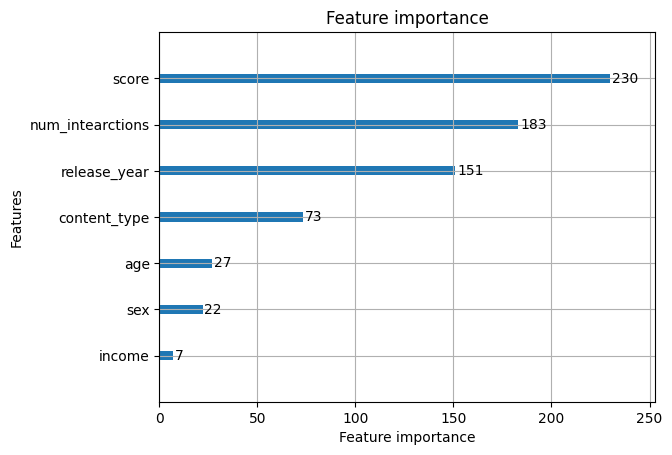

In [ ]:
plot_importance(clf)

### 🔍 SHAP - объяснение предсказаний

**SHAP (SHapley Additive exPlanations):**
- Показывает, как каждый признак влияет на конкретное предсказание
- Summary plot: распределение влияния признаков на всех примерах

**Как читать:**
- Ось X: влияние признака на предсказание (+ или -)
- Цвет: значение признака (красный = высокое, синий = низкое)
- Позиция по Y: важность признака (сверху = более важные)

Это помогает понять логику модели и найти баги/bias.

/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/o.a.lashinin/miniforge3/lib/python3.12/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


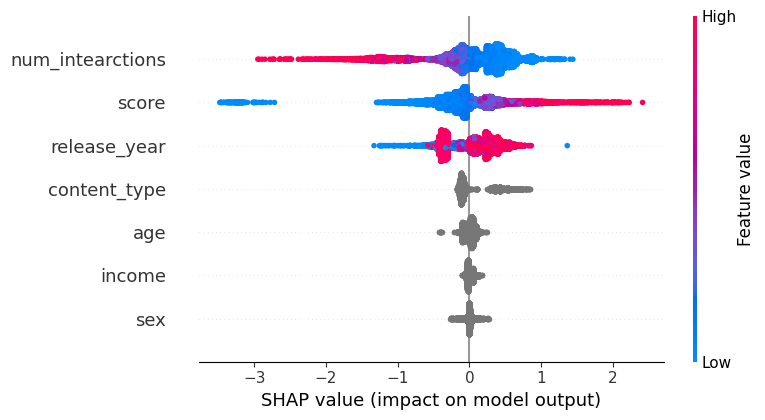

In [ ]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(test_bdf[FEATURES][:10000])
shap.summary_plot(shap_values, test_bdf[FEATURES][:10000])

In [ ]:
from sklearn.metrics import ndcg_score

### 🎯 Оценка на Recall@10

**Метод:**
- Группируем тестовый датасет по user_id
- Для каждого пользователя сортируем рекомендации по score
- Берем топ-10 и считаем Recall

**Результаты:**
- EASE alone: ~7.2% Recall@10
- EASE + LightGBM Classifier: ~7.3% Recall@10

**Небольшое улучшение** показывает, что:
- EASE уже дает хороший baseline
- Классификатор немного улучшает качество за счет признаков
- Есть простор для дальнейшего улучшения!

In [ ]:
def get_recall(x, col, at=3):

    if x.label.sum():
        return x.sort_values(by=col, ascending=False)[:at].label.sum() / x.label.sum()
        
    return 0
    
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'score', at=10)).mean()

/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_20487/3069768473.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'score', at=10)).mean()


np.float64(0.07443682664054849)

In [ ]:
test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'boosting_preds', at=10)).mean()

/var/folders/gw/9vsxt6xx1t39l8d2vg28flr00000gq/T/ipykernel_20487/2811254928.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_bdf.groupby('user_id').apply(lambda x: get_recall(x, 'boosting_preds', at=10)).mean()


np.float64(0.07590597453476983)

## 🏆 LightGBM Ranker - обучение для ранжирования

**Отличие от классификатора:**
- **Классификатор** предсказывает вероятность клика для каждого айтема независимо
- **Ранкер** оптимизирует порядок айтемов внутри группы (для каждого пользователя)

**Почему ранкер лучше для RecSys:**
- Цель - не точность классификации, а правильный порядок рекомендаций
- Использует информацию о группе (пользователе) при обучении
- Оптимизирует метрики ранжирования (NDCG, MAP) напрямую

**LambdaRank:**
- Алгоритм для обучения ранкеров в LightGBM
- Оптимизирует NDCG через градиентный спуск
- Использует попарные сравнения внутри группы

In [ ]:
# Подготовка данных для LightGBM Ranker
# Для ранкера нужны группы (пользователи) и релевантности (labels)

# ВАЖНО: Используем ТОТ ЖЕ split, что и для классификатора!
# train_bdf уже создан выше через train_test_split(bdf)

train_ranker = train_bdf.copy()

# Сортируем по user_id (КРИТИЧЕСКИ ВАЖНО для групп!)
train_ranker = train_ranker.sort_values('user_id').reset_index(drop=True)

# Считаем размеры групп (сколько айтемов у каждого пользователя)
train_groups = train_ranker.groupby('user_id').size().values

print(f"Количество пользователей в train: {len(train_groups)}")
print(f"Средний размер группы: {train_groups.mean():.1f}")
print(f"Всего примеров: {len(train_ranker)}")
print(f"Позитивных примеров: {train_ranker['label'].sum()}")
print(f"Негативных примеров: {(train_ranker['label']==0).sum()}")

Количество пользователей в train: 4084
Средний размер группы: 30.0
Всего примеров: 122520
Позитивных примеров: 884
Негативных примеров: 121636


In [ ]:
# Подготовка тестовых данных
test_ranker = test_bdf.sort_values('user_id').reset_index(drop=True)
test_groups = test_ranker.groupby('user_id').size().values

print(f"Количество пользователей в test: {len(test_groups)}")
print(f"Средний размер группы: {test_groups.mean():.1f}")

Количество пользователей в test: 4084
Средний размер группы: 10.0


In [ ]:
import lightgbm as lgb

In [ ]:
%%time

from lightgbm import LGBMRanker

# Создаем и обучаем ранкер
ranker = LGBMRanker(
    objective='lambdarank',  # Оптимизация для ранжирования
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=0,
    n_jobs=10
)

# Обучаем на тренировочных данных
ranker.fit(
    X=train_ranker[FEATURES],
    y=train_ranker['label'],
    group=train_groups,  # ВАЖНО: указываем группы (пользователей)
    eval_set=[(test_ranker[FEATURES], test_ranker['label'])],
    eval_group=[test_groups],
    callbacks=[lgb.log_evaluation(10)]  # Логируем каждые 10 итераций
)

print("\n✓ Ранкер обучен!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 122520, number of used features: 7
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

In [ ]:

# Также добавим в test_bdf для удобства
test_bdf['ranker_preds'] = ranker.predict(test_bdf[FEATURES])

print("Статистика предсказаний ранкера:")
print(test_bdf['ranker_preds'].describe())

Статистика предсказаний ранкера:
count    40840.000000
mean        -1.116033
std          1.783668
min        -13.283176
25%         -1.708195
50%         -0.795891
75%         -0.082394
max          5.051193
Name: ranker_preds, dtype: float64


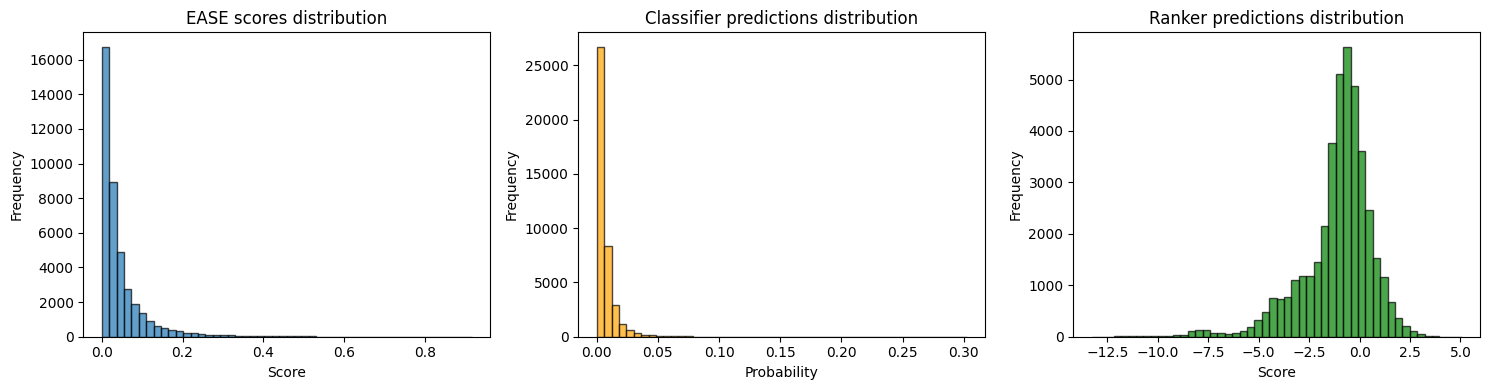


Статистика предсказаний для label=1 (релевантных айтемов):

EASE score:           0.0702 (mean)
Classifier prob:      0.0173 (mean)
Ranker score:         -0.1787 (mean)

Статистика предсказаний для label=0 (нерелевантных айтемов):

EASE score:           0.0463 (mean)
Classifier prob:      0.0072 (mean)
Ranker score:         -1.1234 (mean)

✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0


In [ ]:
# Диагностика: сравним распределения предсказаний

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EASE scores
axes[0].hist(test_bdf['score'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('EASE scores distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

# Classifier predictions
axes[1].hist(test_bdf['boosting_preds'], bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('Classifier predictions distribution')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Frequency')

# Ranker predictions
axes[2].hist(test_bdf['ranker_preds'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Ranker predictions distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Статистика
print("\nСтатистика предсказаний для label=1 (релевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==1]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==1]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==1]['ranker_preds'].mean():.4f} (mean)")

print("\nСтатистика предсказаний для label=0 (нерелевантных айтемов):\n")
print(f"EASE score:           {test_bdf[test_bdf.label==0]['score'].mean():.4f} (mean)")
print(f"Classifier prob:      {test_bdf[test_bdf.label==0]['boosting_preds'].mean():.4f} (mean)")
print(f"Ranker score:         {test_bdf[test_bdf.label==0]['ranker_preds'].mean():.4f} (mean)")

print("\n✅ Хороший знак: если для label=1 средние скоры выше, чем для label=0")

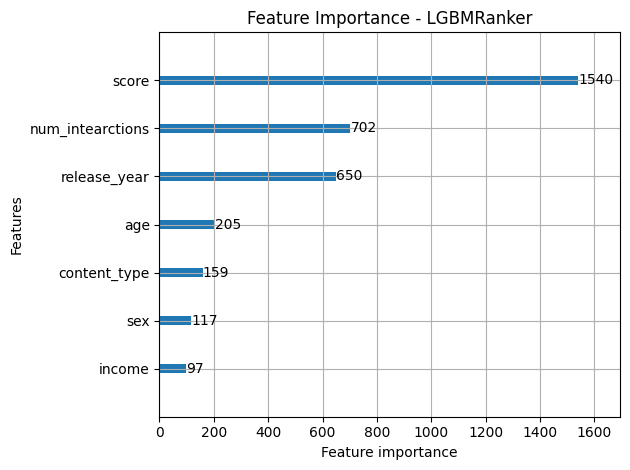

In [ ]:
# Важность признаков в ранкере
plot_importance(ranker)
plt.title('Feature Importance - LGBMRanker')
plt.tight_layout()
plt.show()

### 📊 Важность признаков в Ranker vs Classifier

**Ожидаемые отличия:**
- Ranker может иначе взвешивать признаки, т.к. оптимизирует порядок, а не вероятность
- `score` все равно должен быть важным (это базовое ранжирование от EASE)
- Контентные признаки могут стать более важными для различения между похожими айтемами

## 🎖️ Финальное сравнение трех моделей

Сравним все три подхода по метрикам ранжирования:
1. **EASE** - baseline коллаборативная фильтрация
2. **EASE + LightGBM Classifier** - классификатор поверх EASE
3. **EASE + LightGBM Ranker** - ранкер поверх EASE

In [ ]:
# Сравнение по AUC (способность различать позитивные и негативные примеры)

print("=" * 60)
print("AUC (Area Under ROC Curve)")
print("=" * 60)
print(f"EASE (baseline):        {auc(test_bdf['label'], test_bdf['score']):.4f}")
print(f"EASE + Classifier:      {auc(test_bdf['label'], test_bdf['boosting_preds']):.4f}")
print(f"EASE + Ranker:          {auc(test_bdf['label'], test_bdf['ranker_preds']):.4f}")
print("=" * 60)

AUC (Area Under ROC Curve)
EASE (baseline):        0.6074
EASE + Classifier:      0.7244
EASE + Ranker:          0.6555


In [ ]:
# Сравнение по Recall@K (для разных K)

print("\n" + "=" * 60)
print("Recall@K - доля найденных релевантных айтемов в топ-K")
print("=" * 60)

for K in [1, 2, 5, 10, 20]:
    ease_recall = test_bdf.groupby('user_id', group_keys=False).apply(
        lambda x: get_recall(x, 'score', at=K), 
        include_groups=False
    ).mean()
    
    clf_recall = test_bdf.groupby('user_id', group_keys=False).apply(
        lambda x: get_recall(x, 'boosting_preds', at=K),
        include_groups=False
    ).mean()
    
    ranker_recall = test_bdf.groupby('user_id', group_keys=False).apply(
        lambda x: get_recall(x, 'ranker_preds', at=K),
        include_groups=False
    ).mean()
    
    print(f"\nRecall@{K}:")
    print(f"  EASE (baseline):        {ease_recall:.4f}")
    print(f"  EASE + Classifier:      {clf_recall:.4f} ({(clf_recall/ease_recall-1)*100:+.1f}%)")
    print(f"  EASE + Ranker:          {ranker_recall:.4f} ({(ranker_recall/ease_recall-1)*100:+.1f}%)")

print("=" * 60)


Recall@K - доля найденных релевантных айтемов в топ-K

Recall@1:
  EASE (baseline):        0.0279
  EASE + Classifier:      0.0294 (+5.3%)
  EASE + Ranker:          0.0269 (-3.5%)

Recall@2:
  EASE (baseline):        0.0411
  EASE + Classifier:      0.0429 (+4.2%)
  EASE + Ranker:          0.0424 (+3.0%)

Recall@5:
  EASE (baseline):        0.0610
  EASE + Classifier:      0.0605 (-0.8%)
  EASE + Ranker:          0.0585 (-4.0%)

Recall@10:
  EASE (baseline):        0.0744
  EASE + Classifier:      0.0759 (+2.0%)
  EASE + Ranker:          0.0752 (+1.0%)

Recall@20:
  EASE (baseline):        0.0784
  EASE + Classifier:      0.0784 (+0.0%)
  EASE + Ranker:          0.0784 (+0.0%)
